In [1]:
import os, glob
import pandas as pd
from scipy.stats import ttest_rel
import statsmodels.formula.api as smf

RESULTS_DIR = "/content/drive/MyDrive/tiw_EO_EC_organized/acw_results"
GRADCPT_DIR = "/content/drive/MyDrive/GRAD_OFF/acw_results_cropped"


In [2]:
from google.colab import drive
import os

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
#acw part
files = glob.glob(os.path.join(RESULTS_DIR, "ACW_windows_sub-*_*.csv"))
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["Subject"] = df["Subject"].astype(str)
df["Condition"] = df["Condition"].astype(str)
df["Window"] = df["Window"].astype(int)

print(df.head())
print(df.groupby("Condition").size())

   Subject Condition  Window Channel    ACW_s
0  sub-001        EC       0     Fp1  0.03125
1  sub-001        EC       0     Fp2  0.03125
2  sub-001        EC       0      F3  0.03125
3  sub-001        EC       0      F4  0.03125
4  sub-001        EC       0      C3  0.03125
Condition
EC    367038
EO    367227
dtype: int64


In [4]:
gradcpt_acw_files = glob.glob(os.path.join(GRADCPT_DIR, "ACW_windows_sub-*_*.csv"))
df_gradcpt = pd.concat([pd.read_csv(f) for f in gradcpt_acw_files], ignore_index=True)

df_gradcpt["Subject"] = df_gradcpt["Subject"].astype(str)
df_gradcpt["Condition"] = "GRADCPT"
df_gradcpt["Window"] = df_gradcpt["Window"].astype(int)

print(df_gradcpt.head())

   Subject Condition  Window Channel     ACW_s
0  sub-001   GRADCPT       0     Fp1  0.031250
1  sub-001   GRADCPT       0     Fp2  0.015625
2  sub-001   GRADCPT       0      F3  0.031250
3  sub-001   GRADCPT       0      F4  0.031250
4  sub-001   GRADCPT       0      C3  0.039062


In [5]:
df_all = pd.concat([df, df_gradcpt], ignore_index=True)
df_all["Condition"] = pd.Categorical(df_all["Condition"], categories=["EO", "EC", "GRADCPT"])
print(df_all.groupby("Condition").size())

Condition
EO         367227
EC         367038
GRADCPT    319914
dtype: int64


/tmp/ipykernel_1035/1413668897.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_all.groupby("Condition").size())


In [6]:
# subjects per condition
print(df_all.groupby("Condition")["Subject"].nunique())

# windows per subject per condition (should reveal if gradCPT just has longer recordings)
print(df_all.groupby(["Condition","Subject"])["Window"].nunique().groupby("Condition").mean())


# channels per condition (should be same if montage is identical)
print(df_all.groupby("Condition")["Channel"].nunique())

# check for duplicate files being loaded
print(len(gradcpt_acw_files), len(set(gradcpt_acw_files)))

/tmp/ipykernel_1035/1761786837.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_all.groupby("Condition")["Subject"].nunique())


Condition
EO         28
EC         28
GRADCPT    28
Name: Subject, dtype: int64


/tmp/ipykernel_1035/1761786837.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_all.groupby(["Condition","Subject"])["Window"].nunique().groupby("Condition").mean())


Condition
EO         208.178571
EC         208.071429
GRADCPT    181.357143
Name: Window, dtype: float64
Condition
EO         63
EC         63
GRADCPT    63
Name: Channel, dtype: int64
28 28


/tmp/ipykernel_1035/1761786837.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_all.groupby(["Condition","Subject"])["Window"].nunique().groupby("Condition").mean())
/tmp/ipykernel_1035/1761786837.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_all.groupby("Condition")["Channel"].nunique())


In [7]:
# @title
#preparing data
!pip install -q mne numpy scipy pandas matplotlib seaborn
!pip install -q mne pyvista pyvistaqt ipywidgets seaborn pymatreader
import numpy as np
import mne

df_chan = (
    df_all.groupby(["Subject", "Condition", "Channel"], as_index=False)
      .agg(ACW_s=("ACW_s", "mean"))
)

ec = df_chan[df_chan["Condition"] == "EC"].pivot(
    index="Subject", columns="Channel", values="ACW_s"
)

eo = df_chan[df_chan["Condition"] == "EO"].pivot(
    index="Subject", columns="Channel", values="ACW_s"
)

gradcpt = df_chan[df_chan["Condition"] == "GRADCPT"].pivot(
    index="Subject", columns="Channel", values="ACW_s"
)

# intersect channels across all three conditions so every matrix aligns
common = ec.columns.intersection(eo.columns).intersection(gradcpt.columns)
ec = ec[common]
eo = eo[common]
gradcpt = gradcpt[common]

# also align on subjects present in all three (in case of any subject-level mismatch)
common_subs = ec.index.intersection(eo.index).intersection(gradcpt.index)
ec = ec.loc[common_subs]
eo = eo.loc[common_subs]
gradcpt = gradcpt.loc[common_subs]

X = ec.to_numpy()
Y = eo.to_numpy()
Z = gradcpt.to_numpy()

ch_names = list(common)

#mne info
info = mne.create_info(ch_names=ch_names, sfreq=100, ch_types="eeg")
montage = mne.channels.make_standard_montage("standard_1020")
info.set_montage(montage)
#computing adjecency
adjacency, ch_names_adj = mne.channels.find_ch_adjacency(info, ch_type="eeg")
#reorder data to match adjacency
idx = [ch_names.index(ch) for ch in ch_names_adj if ch in ch_names]
X = X[:, idx]
Y = Y[:, idx]
Z = Z[:, idx]

from scipy.stats import t
#permutation test of both sides version
def run_cluster_test(A, B, label_a, label_b):
    thresh = t.ppf(1 - 0.025, df=A.shape[0] - 1)
    T_obs, clusters, p_values, H0 = mne.stats.permutation_cluster_1samp_test(
        A - B,
        adjacency=adjacency,
        n_permutations=1000,
        tail=0,
        n_jobs=-1,
        threshold=thresh
    )
    print(f"\n--- {label_a} vs {label_b} ---")
    print("Significant clusters:")
    found = False
    for i, p in enumerate(p_values):
        if p < 0.05:
            found = True
            print(f"Cluster {i} p = {p}")
    if not found:
        print("None")
    return T_obs, clusters, p_values

# EC vs EO (your original comparison)
T_ec_eo, clusters_ec_eo, p_ec_eo = run_cluster_test(X, Y, "EC", "EO")

# EO vs GRADCPT
T_eo_gradcpt, clusters_eo_gradcpt, p_eo_gradcpt = run_cluster_test(Y, Z, "EO", "GRADCPT")

# EC vs GRADCPT
T_ec_gradcpt, clusters_ec_gradcpt, p_ec_gradcpt = run_cluster_test(X, Z, "EC", "GRADCPT")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 21.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.5/134.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.9/233.9 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.0/95.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 21.0 MB/s eta 0:00:00


/tmp/ipykernel_1035/3773960814.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_all.groupby(["Subject", "Condition", "Channel"], as_index=False)


Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 63
stat_fun(H1): min=-5.594858939937151 max=1.675317984747737
Running initial clustering …
Found 2 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


--- EC vs EO ---
Significant clusters:
Cluster 0 p = 0.003
stat_fun(H1): min=-3.021358769250681 max=1.709457890472539
Running initial clustering …
Found 1 cluster


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


--- EO vs GRADCPT ---
Significant clusters:
Cluster 0 p = 0.022
stat_fun(H1): min=-6.51391322881264 max=1.4410718805233584
Running initial clustering …
Found 1 cluster


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


--- EC vs GRADCPT ---
Significant clusters:
Cluster 0 p = 0.001


In [20]:
from scipy.stats import t

def run_cluster_test(A, B, label_a, label_b):
    # one-sided threshold: lower tail critical value at alpha = 0.05
    thresh = t.ppf(0.05, df=A.shape[0] - 1)  # negative number

    T_obs, clusters, p_values, H0 = mne.stats.permutation_cluster_1samp_test(
        A - B,
        adjacency=adjacency,
        n_permutations=5000,
        tail=-1,          # test only for negative-going clusters
        n_jobs=-1,
        threshold=thresh,
        seed = 42
    )
    print(f"\n--- {label_a} vs {label_b} (negative clusters only) ---")
    print("Significant clusters:")
    found = False
    for i, p in enumerate(p_values):
        if p < 0.05:
            found = True
            print(f"Cluster {i} p = {p}")
    if not found:
        print("None")
    return T_obs, clusters, p_values, H0


# EC vs EO
T_ec_eo, clusters_ec_eo, p_ec_eo, H0_ec_eo = run_cluster_test(X, Y, "EC", "EO")

# EO vs GRADCPT
T_eo_gradcpt, clusters_eo_gradcpt, p_eo_gradcpt, H0_eo_gradcpt = run_cluster_test(Y, Z, "EO", "GRADCPT")

# EC vs GRADCPT
T_ec_gradcpt, clusters_ec_gradcpt, p_ec_gradcpt, H0_ec_gradcpt = run_cluster_test(X, Z, "EC", "GRADCPT")

stat_fun(H1): min=-5.594858939937151 max=1.675317984747737
Running initial clustering …
Found 1 cluster


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]


--- EC vs EO (negative clusters only) ---
Significant clusters:
Cluster 0 p = 0.0004
stat_fun(H1): min=-3.021358769250681 max=1.709457890472539
Running initial clustering …
Found 2 clusters


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]


--- EO vs GRADCPT (negative clusters only) ---
Significant clusters:
Cluster 0 p = 0.0246
stat_fun(H1): min=-6.51391322881264 max=1.4410718805233584
Running initial clustering …
Found 1 cluster


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]


--- EC vs GRADCPT (negative clusters only) ---
Significant clusters:
Cluster 0 p = 0.0002


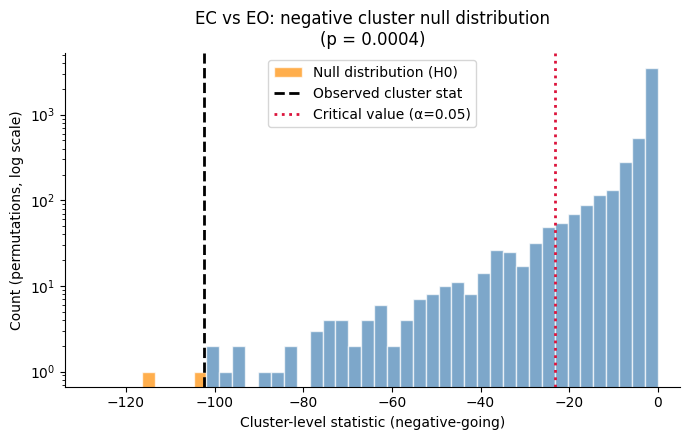

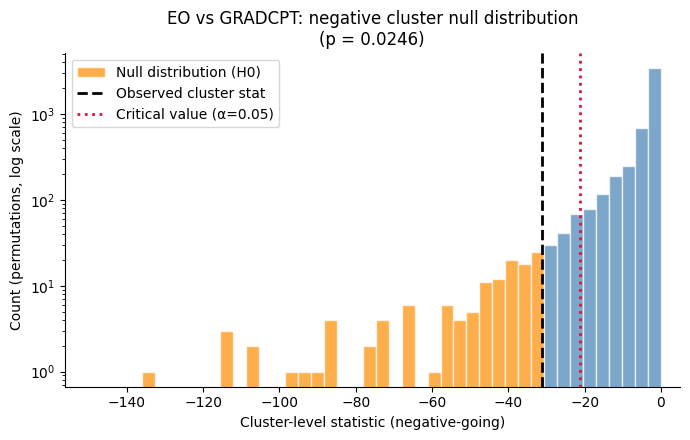

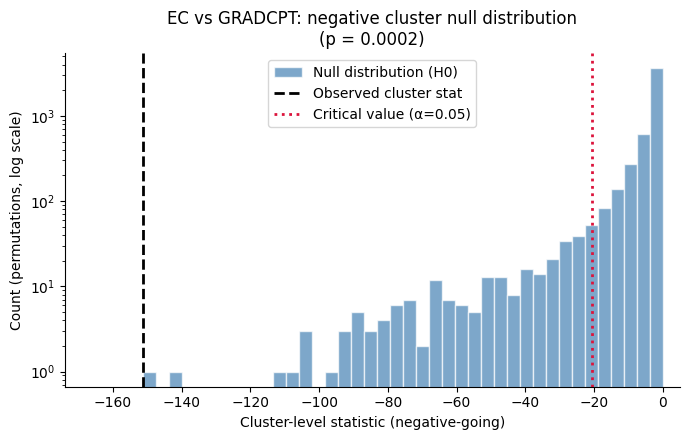

In [21]:
import matplotlib.pyplot as plt
def plot_null_distribution_negative(H0, clusters, T_obs, p_values, label_a, label_b, alpha=0.05):
    if len(clusters) == 0:
        print(f"No clusters found for {label_a} vs {label_b} — nothing to plot.")
        return

    cluster_sums = [T_obs[list(c)].sum() for c in clusters]
    obs_idx = int(np.argmin(cluster_sums))
    obs_stat = cluster_sums[obs_idx]
    p_obs = p_values[obs_idx]
    crit_val = np.quantile(H0, alpha)

    fig, ax = plt.subplots(figsize=(7, 4.5))

    counts, bins, patches = ax.hist(
        H0, bins=40, color="steelblue", alpha=0.7,
        edgecolor="white", label="Null distribution (H0)"
    )

    for i, patch in enumerate(patches):
        bin_center = (bins[i] + bins[i + 1]) / 2
        if bin_center <= obs_stat:
            patch.set_facecolor("darkorange")

    ax.axvline(obs_stat, color="black", linestyle="--", lw=2, label="Observed cluster stat")
    ax.axvline(crit_val, color="crimson", linestyle=":", lw=2,
               label=f"Critical value (α={alpha})")

    ax.set_yscale("log")  # <-- reveals the sparse tail counts
    ax.set_ylabel("Count (permutations, log scale)")

    xmin = min(obs_stat, H0.min()) * 1.15
    xmax = max(H0.max(), 0) + 5
    ax.set_xlim(xmin, xmax)

    ax.set_xlabel("Cluster-level statistic (negative-going)")
    ax.set_title(f"{label_a} vs {label_b}: negative cluster null distribution\n(p = {p_obs:.4f})")
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


plot_null_distribution_negative(H0_ec_eo, clusters_ec_eo, T_ec_eo, p_ec_eo, "EC", "EO")
plot_null_distribution_negative(H0_eo_gradcpt, clusters_eo_gradcpt, T_eo_gradcpt, p_eo_gradcpt, "EO", "GRADCPT")
plot_null_distribution_negative(H0_ec_gradcpt, clusters_ec_gradcpt, T_ec_gradcpt, p_ec_gradcpt, "EC", "GRADCPT")

In [22]:
alpha = 0.05
comparisons = {
    "EC vs EO": (clusters_ec_eo, p_ec_eo),
    "EO vs GRADCPT": (clusters_eo_gradcpt, p_eo_gradcpt),
    "EC vs GRADCPT": (clusters_ec_gradcpt, p_ec_gradcpt),
}

for label, (clusters, p_values) in comparisons.items():
    print(f"\n=== {label} ===")
    for i, p in enumerate(p_values):
        if p < alpha:
            ch_idx = clusters[i]

            print(f"\nCluster {i}")
            print(f"p-value = {p}")

            print("Channels:")
            print(np.array(info.ch_names)[ch_idx])


=== EC vs EO ===

Cluster 0
p-value = 0.0004
Channels:
['C1' 'C3' 'CP1' 'CP2' 'CP5' 'CPz' 'Cz' 'F2' 'FC1' 'FC2' 'O1' 'O2' 'Oz'
 'P1' 'P2' 'P3' 'P4' 'P5' 'P6' 'P7' 'P8' 'PO3' 'PO4' 'PO7' 'PO8' 'POz'
 'Pz' 'TP9']

=== EO vs GRADCPT ===

Cluster 0
p-value = 0.0246
Channels:
['CP4' 'O1' 'O2' 'Oz' 'P2' 'P4' 'P6' 'P8' 'PO4' 'PO8' 'Pz' 'TP10' 'TP8']

=== EC vs GRADCPT ===

Cluster 0
p-value = 0.0002
Channels:
['C1' 'C2' 'C3' 'CP1' 'CP2' 'CP4' 'CP5' 'CP6' 'CPz' 'Cz' 'F1' 'F2' 'FC1'
 'FC2' 'FC3' 'Fz' 'O1' 'O2' 'Oz' 'P1' 'P2' 'P3' 'P4' 'P5' 'P6' 'P7' 'P8'
 'PO3' 'PO4' 'PO7' 'PO8' 'POz' 'Pz' 'TP10' 'TP7' 'TP8' 'TP9']


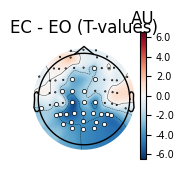

<Figure size 640x480 with 0 Axes>

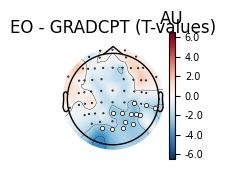

<Figure size 640x480 with 0 Axes>

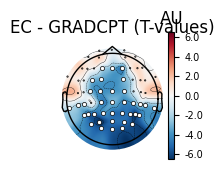

<Figure size 640x480 with 0 Axes>

In [23]:
import matplotlib.pyplot as plt

def plot_cluster_topomap(T_obs, clusters, p_values, info, label_a, label_b, vmax):
    sig_mask = np.zeros(len(T_obs), dtype=bool)
    for i, p in enumerate(p_values):
        if p < alpha:
            sig_mask[list(clusters[i])] = True

    evoked = mne.EvokedArray(T_obs[:, np.newaxis], info, tmin=0)

    evoked.plot_topomap(
        times=0,
        scalings=1,
        time_format=f"{label_a} - {label_b} (T-values)",
        cmap="RdBu_r",
        vlim=(-vmax, vmax),   # shared scale, no longer computed per-plot
        mask=sig_mask[:, np.newaxis],
        mask_params=dict(marker='o', markerfacecolor='w', markeredgecolor='k',
                         linewidth=0, markersize=6),
        colorbar=True
    )

    plt.suptitle(f"Significant {label_a} - {label_b} cluster")
    plt.show()

# compute one shared vmax across all three comparisons
global_vmax = max(
    np.abs(T_ec_eo).max(),
    np.abs(T_eo_gradcpt).max(),
    np.abs(T_ec_gradcpt).max()
)

# EC vs EO
plot_cluster_topomap(T_ec_eo, clusters_ec_eo, p_ec_eo, info, "EC", "EO", vmax=global_vmax)

# EO vs GRADCPT
plot_cluster_topomap(T_eo_gradcpt, clusters_eo_gradcpt, p_eo_gradcpt, info, "EO", "GRADCPT", vmax=global_vmax)

# EC vs GRADCPT
plot_cluster_topomap(T_ec_gradcpt, clusters_ec_gradcpt, p_ec_gradcpt, info, "EC", "GRADCPT", vmax=global_vmax)

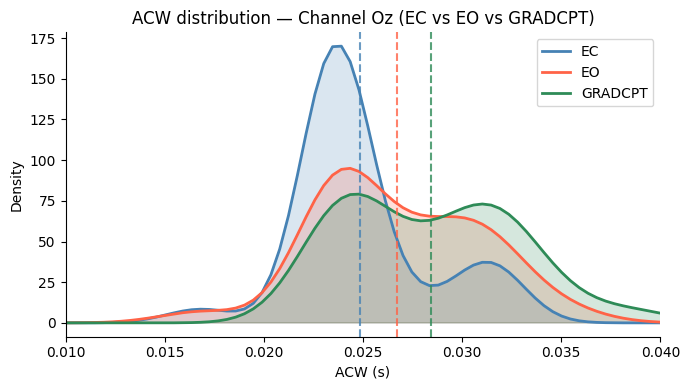

In [24]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

# Filter for Oz channel
Oz = df_chan[df_chan["Channel"] == "Oz"]

ec_vals = Oz[Oz["Condition"] == "EC"]["ACW_s"].values
eo_vals = Oz[Oz["Condition"] == "EO"]["ACW_s"].values
gradcpt_vals = Oz[Oz["Condition"] == "GRADCPT"]["ACW_s"].values

# KDE
x = np.linspace(min(ec_vals.min(), eo_vals.min(), gradcpt_vals.min()) - 0.1,
                max(ec_vals.max(), eo_vals.max(), gradcpt_vals.max()) + 0.1, 500)

kde_ec = gaussian_kde(ec_vals)
kde_eo = gaussian_kde(eo_vals)
kde_gradcpt = gaussian_kde(gradcpt_vals)

# Plot
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x, kde_ec(x), color="steelblue", lw=2, label="EC")
ax.plot(x, kde_eo(x), color="tomato", lw=2, label="EO")
ax.plot(x, kde_gradcpt(x), color="seagreen", lw=2, label="GRADCPT")

ax.fill_between(x, kde_ec(x), alpha=0.2, color="steelblue")
ax.fill_between(x, kde_eo(x), alpha=0.2, color="tomato")
ax.fill_between(x, kde_gradcpt(x), alpha=0.2, color="seagreen")

ax.axvline(ec_vals.mean(), color="steelblue", lw=1.5, ls="--", alpha=0.8)
ax.axvline(eo_vals.mean(), color="tomato", lw=1.5, ls="--", alpha=0.8)
ax.axvline(gradcpt_vals.mean(), color="seagreen", lw=1.5, ls="--", alpha=0.8)

ax.set_xlabel("ACW (s)")
ax.set_ylabel("Density")
ax.set_title("ACW distribution — Channel Oz (EC vs EO vs GRADCPT)")
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0.01, 0.04)
plt.tight_layout()
plt.show()

In [13]:
#ac part over time
def compute_acf(signal, sfreq, max_lag_ms=150):
    signal = np.asarray(signal, dtype=float)
    signal = signal - np.mean(signal) #mean centering

    if np.allclose(signal, 0):  #check the signal isnt full of zeros
        return np.full(int(max_lag_ms / 1000 * sfreq) + 1, np.nan)

    acf = np.correlate(signal, signal, mode="full")
    acf = acf[acf.size // 2:]

    if acf[0] == 0: #first autocorrelation is the signal with himself, shouldnt be zero as we divide by zero later
        return np.full(int(max_lag_ms / 1000 * sfreq) + 1, np.nan)

    acf = acf / acf[0]

    max_lag = int(max_lag_ms / 1000 * sfreq) #max lag is set to 150 ms
    return acf[:max_lag + 1]

In [14]:
def compute_acf_sliding(raw, window_sec=5, step_sec=1, max_lag_ms=150):
    """Compute continuous ACF per EEG channel for each sliding window."""
    data = raw.get_data(picks="eeg")
    sfreq = raw.info["sfreq"]

    window = int(window_sec * sfreq)
    step = int(step_sec * sfreq)
    n_samples = data.shape[1]

    acf_epochs = []

    for start in range(0, n_samples - window + 1, step): #dividing to windows
        stop = start + window
        segment = data[:, start:stop]

        acf_channels = []
        for ch in segment:
            acf = compute_acf(ch, sfreq, max_lag_ms=max_lag_ms)
            acf_channels.append(acf)

        acf_epochs.append(acf_channels)

    return np.array(acf_epochs)
    #computing acf for 20 lags per window

In [16]:
PROJECT_DIR = "/content/drive/MyDrive/tiw_EO_EC_organized/preprocessed_organized/cleaned_organized"
PROJECT_DIR_CPT = "/content/drive/MyDrive/GRAD_OFF/Raw_files/preprocessed_organized/cleaned_organized"

files = glob.glob(os.path.join(PROJECT_DIR, "*.fif"))
ec_files = sorted([f for f in files if "ECOFF" in os.path.basename(f)])
eo_files = sorted([f for f in files if "EOOFF" in os.path.basename(f)])

grad_files = sorted(glob.glob(os.path.join(PROJECT_DIR_CPT, "*.fif")))

print("EC files:", len(ec_files))
print("EO files:", len(eo_files))
print("GRADCPT files:", len(grad_files))

EC files: 28
EO files: 28
GRADCPT files: 28


In [17]:
all_subject_mean_ec = []
all_subject_mean_eo = []
all_subject_mean_grad = []

for path in ec_files:
    raw = mne.io.read_raw_fif(path, preload=True, verbose=False)
    raw.resample(128)
    raw.pick_channels(["Oz"])

    acf = compute_acf_sliding(raw, window_sec=5, step_sec=1, max_lag_ms=150)
    subj_mean = np.nanmean(acf, axis=(0,1))   # windows + channel

    all_subject_mean_ec.append(subj_mean)
    del raw, acf

for path in eo_files:
    raw = mne.io.read_raw_fif(path, preload=True, verbose=False)
    raw.resample(128)
    raw.pick_channels(["Oz"])

    acf = compute_acf_sliding(raw, window_sec=5, step_sec=1, max_lag_ms=150)
    subj_mean = np.nanmean(acf, axis=(0,1))

    all_subject_mean_eo.append(subj_mean)
    del raw, acf
for path in grad_files:
    raw = mne.io.read_raw_fif(path, preload=True, verbose=False)
    # crop to actual task window (S245 = start, S155 = stop)
    start_events = [ann['onset'] for ann in raw.annotations if ann['description'] == 'S245']
    stop_events  = [ann['onset'] for ann in raw.annotations if ann['description'] == 'S155']
    if start_events and stop_events:
        raw.crop(tmin=min(start_events), tmax=max(stop_events))
    else:
        print(f"WARNING: no task markers found for {os.path.basename(path)} — skipping crop")
    raw.resample(128)
    raw.pick_channels(["Oz"])

    acf = compute_acf_sliding(raw, window_sec=5, step_sec=1, max_lag_ms=150)
    subj_mean = np.nanmean(acf, axis=(0,1))

    all_subject_mean_grad.append(subj_mean)
    del raw, acf

mean_acf_gradcpt = np.nanmean(np.array(all_subject_mean_grad), axis=0)
mean_acf_ec = np.nanmean(np.array(all_subject_mean_ec), axis=0)
mean_acf_eo = np.nanmean(np.array(all_subject_mean_eo), axis=0)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy functi

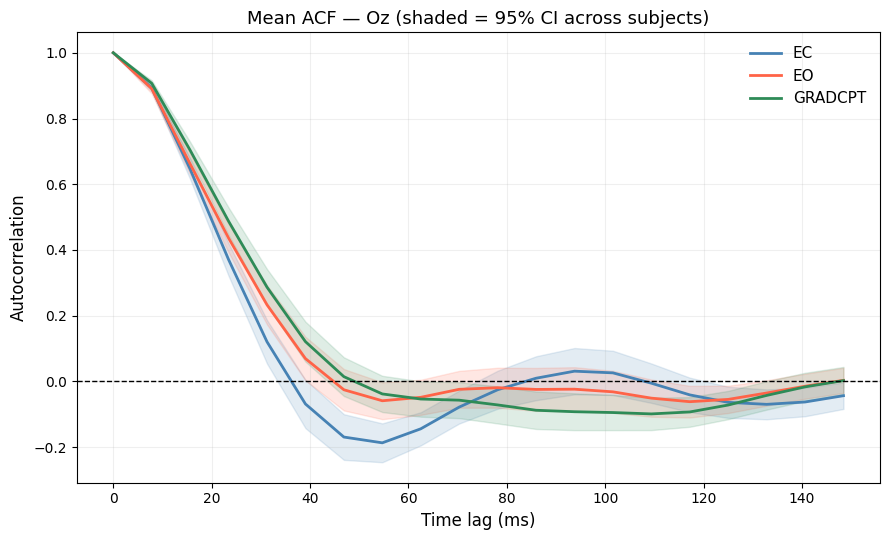

In [18]:
from scipy.stats import sem
# graph with confidence intervals
# convert subject lists to arrays: shape (n_subjects, n_lags)
ec_arr = np.array(all_subject_mean_ec)
eo_arr = np.array(all_subject_mean_eo)
grad_arr = np.array(all_subject_mean_grad)

# recompute means
mean_acf_ec = np.nanmean(ec_arr, axis=0)
mean_acf_eo = np.nanmean(eo_arr, axis=0)
mean_acf_gradcpt = np.nanmean(grad_arr, axis=0)

# SEM per lag
sem_ec = sem(ec_arr, axis=0, nan_policy="omit")
sem_eo = sem(eo_arr, axis=0, nan_policy="omit")
sem_grad = sem(grad_arr, axis=0, nan_policy="omit")

# 95% CI = mean ± 1.96 * SEM
ci_mult = 1.96

lags_ms = np.arange(len(mean_acf_ec)) / 128 * 1000

plt.figure(figsize=(9,5.5))

plt.plot(lags_ms, mean_acf_ec, label="EC", color="steelblue", linewidth=2)
plt.fill_between(lags_ms, mean_acf_ec - ci_mult*sem_ec, mean_acf_ec + ci_mult*sem_ec,
                  color="steelblue", alpha=0.15)

plt.plot(lags_ms, mean_acf_eo, label="EO", color="tomato", linewidth=2)
plt.fill_between(lags_ms, mean_acf_eo - ci_mult*sem_eo, mean_acf_eo + ci_mult*sem_eo,
                  color="tomato", alpha=0.15)

plt.plot(lags_ms, mean_acf_gradcpt, label="GRADCPT", color="seagreen", linewidth=2)
plt.fill_between(lags_ms, mean_acf_gradcpt - ci_mult*sem_grad, mean_acf_gradcpt + ci_mult*sem_grad,
                  color="seagreen", alpha=0.15)

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Time lag (ms)", fontsize=12)
plt.ylabel("Autocorrelation", fontsize=12)
plt.title("Mean ACF — Oz (shaded = 95% CI across subjects)", fontsize=13)
plt.legend(fontsize=11, frameon=False)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [19]:
#confidence interval stats
target_lag_ms = 30  # change accordingly

lag_idx = np.argmin(np.abs(lags_ms - target_lag_ms))
print(f"EC ACF at {target_lag_ms}ms: {mean_acf_ec[lag_idx]:.3f} "
      f"[{mean_acf_ec[lag_idx]-ci_mult*sem_ec[lag_idx]:.3f}, "
      f"{mean_acf_ec[lag_idx]+ci_mult*sem_ec[lag_idx]:.3f}]")

EC ACF at 30ms: 0.121 [0.054, 0.187]
